# Time-resolved noise-correlation PSTHs, split by trial condition
For each time bin (sliding window), the mean within-region pairwise spike-count correlation across trials of a condition level. Shown for an example session split by contrast / side / choice / outcome / block, then averaged across sessions with brain-region selection.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from scipy.ndimage import uniform_filter1d
from iblatlas.regions import BrainRegions
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [18]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'

REGION_LEVEL = 'cosmos'    # 'cosmos' | 'beryl'
DROP = ['root', 'void']
DROP = [ 'void']
WIN_BINS = 5              # sliding-window width (bins) for the spike-count correlation
MIN_NEURONS = 15           # per region in a session
MIN_LEVEL_TRIALS = 15      # min trials per condition level
SPLIT_VARS = ['contrast', 'side', 'choice', 'feedback', 'block']
SMOOTH_MODE = 'causal'     # 'causal' (uses only bins <= t; no future leakage) or 'centered'
BALANCE_LEVELS = True      # subsample each condition level to equal #trials
SEED = 0
SPLIT_VARS = ['contrast', 'feedback']

trials_df = pd.read_parquet(trials_path)
trial_beh = {s: g.set_index('trial_id')[['choice', 'correct', 'block']] for s, g in trials_df.groupby('session')}
br = BrainRegions()
print("params set")

params set


## Compute noise-correlation PSTHs per session x region x condition level

In [19]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
T = len(tcols)

def rsc_curve(A):
    """A: neurons x trials x T (windowed rates). Mean off-diagonal correlation per time bin."""
    nN, nL, Tn = A.shape
    if nL < 3 or nN < 2: return np.full(Tn, np.nan)
    mean = np.nanmean(A, axis=1, keepdims=True)
    std = np.nanstd(A, axis=1, ddof=1, keepdims=True)
    Z = (A - mean) / std
    Z[~np.isfinite(Z)] = np.nan
    s = np.nansum(Z, axis=0)                       # trials x T
    sumsq = np.nansum(s ** 2, axis=0)              # T
    nvalid = ((np.isfinite(std[:, 0, :])) & (std[:, 0, :] > 0)).sum(0).astype(float)
    with np.errstate(invalid='ignore', divide='ignore'):
        off = (sumsq / (nL - 1) - nvalid) / (nvalid * (nvalid - 1))
    off[nvalid < 2] = np.nan
    return off

def smooth_time(A, W, mode):
    """Moving average of width W along the time axis (axis=2)."""
    if mode == 'centered':
        return uniform_filter1d(A, W, axis=2, mode='nearest')
    # causal: trailing mean using only bins <= t (expanding window for the first W bins)
    c = np.cumsum(A, axis=2)
    out = np.empty_like(A)
    out[..., :W] = c[..., :W] / np.arange(1, W + 1)
    out[..., W:] = (c[..., W:] - c[..., :-W]) / W
    return out

rng = np.random.default_rng(SEED)
records = []
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        beh = trial_beh.get(session)
        if beh is None: continue
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)

        neurons = sorted(d['nuid'].unique()); nidx = {n: k for k, n in enumerate(neurons)}
        trials = sorted(d['trial_id'].unique()); tix = {t: k for k, t in enumerate(trials)}
        A = np.full((len(neurons), len(trials), T), np.nan)
        A[d['nuid'].map(nidx).values, d['trial_id'].map(tix).values, :] = d[tcols].values

        # per-neuron region (optionally Cosmos)
        na = d.groupby('nuid')['area'].first().reindex(neurons)
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(na.dropna().unique(), br.acronym2acronym(na.dropna().unique(), mapping='Cosmos')))
            na = na.map(cmap)
        neu_area = na.values

        # trial metadata
        cond = d.drop_duplicates('trial_id').set_index('trial_id')['condition'].reindex(trials)
        meta = pd.DataFrame(index=trials)
        meta['side'] = cond.str.split('_').str[0].values
        meta['contrast'] = cond.str.split('_').str[1].astype(float).values
        meta['choice'] = beh['choice'].reindex(trials).values
        meta['feedback'] = beh['correct'].reindex(trials).map({1.0: 'correct', 0.0: 'incorrect'}).values
        meta['block'] = beh['block'].reindex(trials).values

        for region in pd.unique(neu_area):
            if region is None or (isinstance(region, float) and np.isnan(region)): continue
            ni = np.where(neu_area == region)[0]
            if len(ni) < MIN_NEURONS: continue
            Asub = A[ni]
            complete = ~np.isnan(Asub).any(axis=(0, 2))
            if complete.sum() < MIN_LEVEL_TRIALS: continue
            Aw = smooth_time(Asub[:, complete, :], WIN_BINS, SMOOTH_MODE)
            cmeta = meta.iloc[np.where(complete)[0]]
            for var in SPLIT_VARS:
                vals = cmeta[var]
                levels = [lv for lv in vals.dropna().unique() if (vals == lv).sum() >= MIN_LEVEL_TRIALS]
                if len(levels) < 2:
                    continue
                n_target = min((vals == lv).sum() for lv in levels) if BALANCE_LEVELS else None
                for level in levels:
                    idx = np.where((vals == level).values)[0]
                    if BALANCE_LEVELS:
                        idx = rng.choice(idx, n_target, replace=False)
                    records.append(dict(session=session, region=region, var=var, level=level,
                                        n_neurons=len(ni), n_trials=int(len(idx)),
                                        curve=rsc_curve(Aw[:, idx, :])))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")

curves = pd.DataFrame(records)
print(f"Computed {len(curves)} curves | {curves['session'].nunique()} sessions | "
      f"regions: {sorted(curves['region'].unique())}")

  100/380 files...
  200/380 files...
  300/380 files...
Computed 5763 curves | 236 sessions | regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH', 'root']


## Plot helpers

In [20]:
def _order_levels(var, levels):
    if var in ('contrast', 'block'):
        return sorted(levels, key=lambda x: float(x))
    return sorted(levels, key=str)

def _agg(df_sub):
    """-> dict level -> (sessions x T) matrix (region-averaged within session)."""
    out = {}
    for level, g in df_sub.groupby('level'):
        per_sess = g.groupby('session')['curve'].apply(lambda cs: np.nanmean(np.vstack(cs.values), axis=0))
        out[level] = np.vstack(per_sess.values)
    return out

def plot_grid(df, session=None, regions=None, title=''):
    d = df.copy()
    if session is not None: d = d[d['session'] == session]
    if regions is not None: d = d[d['region'].isin(regions)]
    vars_present = [v for v in SPLIT_VARS if v in d['var'].unique()]
    fig, axes = plt.subplots(1, len(vars_present), figsize=(4.2 * len(vars_present), 4.2), squeeze=False)
    for k, var in enumerate(vars_present):
        ax = axes[0][k]
        agg = _agg(d[d['var'] == var])
        levels = _order_levels(var, list(agg.keys()))
        cmap = plt.cm.viridis(np.linspace(0, 1, len(levels))) if var in ('contrast', 'block')                else plt.cm.tab10(np.linspace(0, 1, len(levels)))
        for c, level in zip(cmap, levels):
            M = agg[level]; mean = np.nanmean(M, axis=0)
            ax.plot(tsec, mean, color=c, lw=2, label=f'{level} (N={M.shape[0]})')
            if M.shape[0] > 1:
                sem = np.nanstd(M, axis=0) / np.sqrt(M.shape[0])
                ax.fill_between(tsec, mean - sem, mean + sem, color=c, alpha=0.15)
        ax.axvline(0, color='black', ls='--', alpha=0.5, lw=1.2)
        ax.set_xlabel('Time (s)'); ax.set_ylabel('mean r_SC'); ax.set_title(var, fontsize=11)
        ax.set_xlim([-0.3, 0.6]); ax.legend(fontsize=7); sns.despine(ax=ax, offset=4)
    fig.suptitle(title, y=1.03, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

## Example session

Example session: 4ecb5d24-f5cc-402c-be28-9d0f7cb14b3a  (regions: ['CNU', 'HY', 'Isocortex', 'OLF', 'root'])


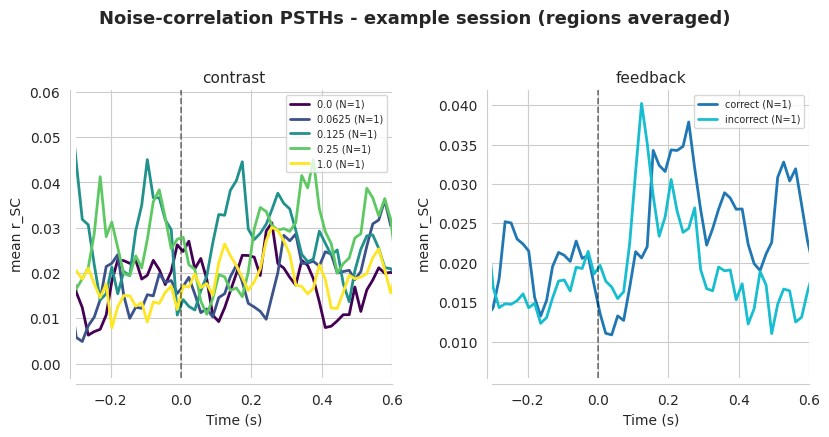

In [21]:
# pick the session with the most neuron-mass as the example
ex = (curves.groupby('session')['n_neurons'].sum().idxmax())
print(f"Example session: {ex}  (regions: {sorted(curves[curves.session==ex]['region'].unique())})")
plot_grid(curves, session=ex, title=f'Noise-correlation PSTHs - example session (regions averaged)')

## Averaged across sessions (select regions or all)

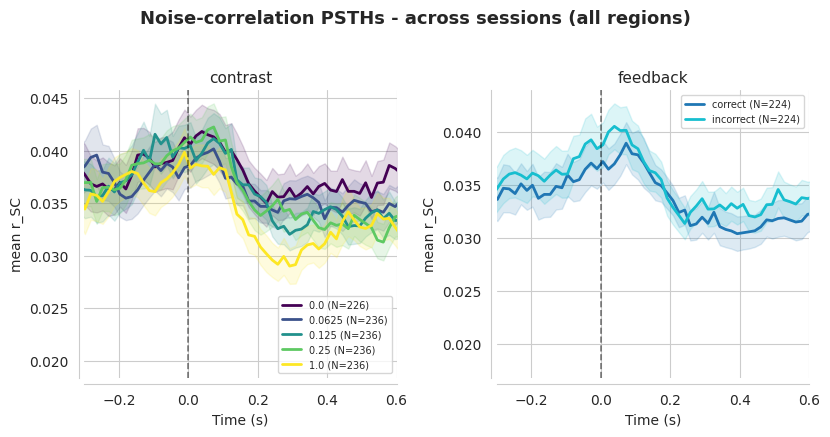

In [22]:
# REGIONS = None -> average across all regions; or a list e.g. ['Isocortex'] / ['TH','HPF']
REGIONS = None
plot_grid(curves, regions=REGIONS,
          title=f'Noise-correlation PSTHs - across sessions ({"all regions" if REGIONS is None else REGIONS})')

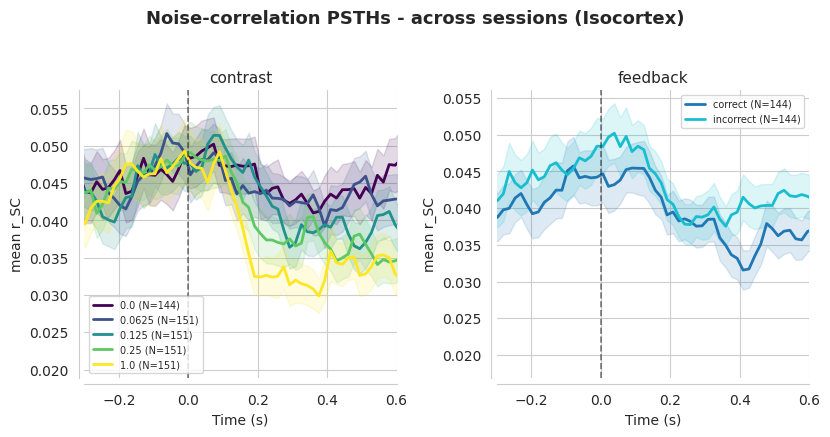

In [36]:
# example with a specific region
plot_grid(curves, regions=['Isocortex', 'TH'],
          title='Noise-correlation PSTHs - across sessions (Isocortex)')